# Option B : Cost and Performance Optimization for Application Deployment and Scaling

## DIA_4
### Axel Juillard, Timothee Joliot, Leo-Paul Chauvigne


## Problem context

 Modern Machine Learning models, especially in fields like Deep Learning, are becoming increasingly
 large and complex. Training these models on a single machine can take weeks or even months, creating a
 significant bottleneck in the AI development cycle. To accelerate this process, companies use distributed
 training, where the computational workload is spread across multiple machines in a cloud environment.
 This approach can drastically reduce training time, but it introduces a major challenge: cost and
 resource management.

 Efficiently allocating cloud resources for a distributed training job is a critical problem in MLOps (Machine Learning Operations). A poorly configured cluster can lead to enormous cloud bills with little performance gain, or worse, training failures. Conversely, an optimal configuration can save thousands of dollars and significantly shorten the time to model deployment.

## Problem Definition

 An AI team needs to train a large-scale machine learning model using a distributed architecture on
 a cloud platform. The objective is to configure the training cluster to minimize the total hourly
 infrastructure cost while ensuring the training process is stable and efficient.

### ---

In other words, we look at a machine learning application running in the cloud. It is made of several components that work together (For example : Data Preprocessing, Feature Engineering, Model Training). Each of these components can run on several virtual machines at the same time to handle a higher workload in parallel, which is what we call distributed training.


The cloud provider here gives us different VM types with different CPU, RAM and price per hour with there being a limit to how many virtual machines of the same type we can use.

Our job is to decide based on the workload:

- How many VMs of each type we rent
- How we place the different components of the application on these VMs  

So as to minimize the cost of renting the VM all the while having enough computing power to assure a stable handling of the workload.

From an algorithmic point of view, this is a hard combinatorial optimisation problem: there are many possible combinations of VM counts and component replicas, and checking feasibility involves several constraints. We will tackle this using two AI algorithms from the course (one exact or constraint-based approach and one heuristic or metaheuristic approach) and compare their performance.

## Problem Constraints

This problem is composed of 3 main constraints which we will adress in our solution :

- Resource sufficiency. The total resources (CPU and RAM) provided by the chosen VMs must
 be greater than or equal to the total resources required by all component replicas combined.
- Training stability (Queuing Concept). To prevent bottlenecks, the cluster must be able to
 process incoming requests faster than they arrive.
- VM availability. The number of provisioned VMs of a given type cannot exceed the availability
 limit specified in the catalogue.

## Problem Data

### "VM_Catalogue.xlsx"
   - Each row describes one VM type  
   - Columns: 
      - type identifier, 
      - CPU capacity, 
      - RAM capacity, 
      - hourly cost, 
      - maximum available quantity  
   - This defines the search space of possible VM choices and is used to compute the cost of a deployment

### "Workload.xlsx"  
   - Time series of incoming request rates  
   - Columns: time index and input_rate  
   - This defines the load that the system must be able to handle and is used to compute how many replicas are needed for stability

## Data Loading & Exploration

In [2]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


### Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Data loading

In [4]:
# Paths of data files
VM_CATALOGUE_PATH = "OptionB_Data\VM_Catalogue.xlsx"
WORKLOAD_PATH = "OptionB_Data\Workload.xlsx"

vmDF = pd.read_excel(VM_CATALOGUE_PATH, header=1)
workloadDF = pd.read_excel(WORKLOAD_PATH)

In [5]:
vmDF.head(18)

,Type,CPU,RAM,Cost,Quantity
0,T00,1,3.75,0.1914,10
1,T01,2,1.80,0.2104,10
2,T02,2,7.50,0.2684,10
3,T03,2,13.00,0.2944,10
4,T04,4,3.60,0.3064,10
5,T05,4,15.00,0.4224,10
6,T06,4,26.00,0.4744,10
7,T07,8,7.20,0.4984,10
8,T08,8,30.00,0.7304,10
9,T09,8,52.00,0.8344,10


In [6]:
workloadDF.head()

,time,input_rate
0,0,340
1,1,469
2,2,541
3,3,378
4,4,396


### Quick validation of loaded data

Before moving on to modeling, we sanity-check the datasets we just loaded to confirm shapes, columns, and missing values.


In [7]:
print('VM catalogue columns:', list(vmDF.columns), '\n')
print('Workload columns:', list(workloadDF.columns))


VM catalogue columns: ['Type', 'CPU', 'RAM', 'Cost', 'Quantity'] 

Workload columns: ['time', 'input_rate']


In [8]:
print(f'VM catalogue shape: {vmDF.shape}\n')
print(f'Workload shape: {workloadDF.shape}')



VM catalogue shape: (17, 5)

Workload shape: (1259, 2)


In [9]:
print('Missing values per column (VM catalogue):')
print(vmDF.isna().sum(), '\n')

print('Missing values per column (Workload):')
print(workloadDF.isna().sum())

Missing values per column (VM catalogue):
Type        0
CPU         0
RAM         0
Cost        0
Quantity    0
dtype: int64 

Missing values per column (Workload):
time          0
input_rate    0
dtype: int64


All expected columns listed in the project statement are present, shapes match the described schema (17 VM types, 1,259 workload points), and there are no missing values.


### Problem formulation

We are modeling the problem for one application made of 4 components.

For each component i we know:

  - mu_i = service rate of component i (how fast one replica can work, for example its requests per second)
  
  - cpu_req_i (how much CPU one replica needs)

  - ram_req_i (ow much RAM one replica needs)

  
  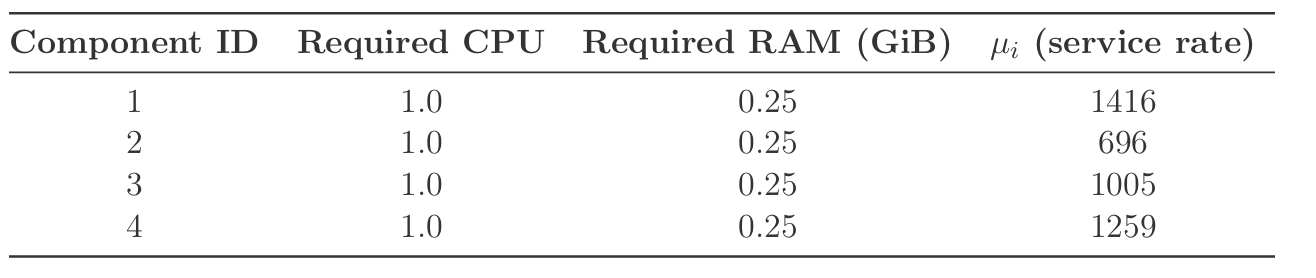


In [10]:
# Component parameters
# For each parameter we define a dictionary contatining the specifications for each component.
cpu_req = {
    0: 1.0,
    1: 1.0,
    2: 1.0,
    3: 1.0,
}

ram_req = {
    0: 0.25,
    1: 0.25,
    2: 0.25,
    3: 0.25,
}

mu = {
    0: 1416,
    1: 696,    
    2: 1005,   
    3: 1259,   
}

For each VM type j in the catalogue we know:

  - CPU_j (how much CPU one VM of this type has)

  - RAM_j (how much RAM one VM of this type has)

  - Cost_j (how much it costs per hour)

  - Qty_j (the maximum number of VMs of this type we are allowed to rent)

In [11]:
# We transform the VM catalogue dataframe into dictionaries for ease of use later on when coding the algorithms

cpu_vm = vmDF["CPU"].to_dict()
ram_vm = vmDF["RAM"].to_dict()
cost_vm = vmDF["Cost"].to_dict()
qty_vm  = vmDF["Quantity"].to_dict()

From the workload file we load the input rate / arrival rate, λi

For each λi we want to choose r_i, the number of replicas of component i and nb_of_type_j_machine, the number of VMs of type j that we rent so as to minimize the objective function : 

Cost(r, x) = sum over j of (Cost_j * nb_of_type_j_machine)

Satisfying the constraints : 

- r_i * mu_i > λi (stability)

    Constraint : Each component must have enough replicas to keep up with the incoming requests.

- [sum over i of (cpu_req_i * r_i)] <= [sum over j of (CPU_j * nb_of_type_j_machine)]
    
    Constraint: total CPU demand ≤ total CPU capacity.

- [ sum over i of (ram_req_i * r_i) ] <= [sum over j of (RAM_j * nb_of_type_j_machine) ]
    
    Constraint: total RAM demand ≤ total RAM capacity.

In [12]:
# We choose lambda_ref value, the maximum workload arrival rate.
# This way we ensure that our cluster can handle the maximum workload satisfying the stability constraint.

lambda_ref = workloadDF["input_rate"].max()

# We define the function that will be used in both algortihms to verify the stability constraint.
def is_stable(lambda_i, component_i, r_list):
    return lambda_i < mu[component_i] * r_list[component_i]

# We define the function that outputs the total cpu demand for the sum of all replicas of all components.
def total_cpu_demand(r_list):
    return sum(cpu_req[i] * r_list[i] for i in range(4))

# We define the function that outputs the total cpu demand for the sum of all replicas of all components.
def total_ram_demand(r_list):
    return sum(ram_req[i] * r_list[i] for i in range(4))

# Calculates the total cpu capacity of all VMs rented.
def total_cpu_capacity(nb_of_type_j_machine):
    return sum(cpu_vm[j] * nb_of_type_j_machine[j] for j in nb_of_type_j_machine)

# Calculates the total ram capacity of all VMs rented.
def total_ram_capacity(nb_of_type_j_machine):
    return sum(ram_vm[j] * nb_of_type_j_machine[j] for j in nb_of_type_j_machine)

# Returns a boolean to verify if the hardware of the VMs rented is enough to host all replicas of all components.
def is_capacity_enough(r_list, nb_of_type_j_machine):
    return (
        total_cpu_demand(r_list) <= total_cpu_capacity(nb_of_type_j_machine)
        and total_ram_demand(r_list) <= total_ram_capacity(nb_of_type_j_machine)
    )

# Returns a boolean to verify if the quantity of VMs rented is available in the catalogue.
def are_available(nb_of_type_j_machine):
    for j in nb_of_type_j_machine:
        if nb_of_type_j_machine[j] < 0 or nb_of_type_j_machine[j] > qty_vm[j]:
            return False
    return True

# Returns a boolean to verify if all constraints are respected.
def is_valid_config(r, x):
    return is_stable(r) and is_capacity_enough(r, x) and are_available(x)

# Calculates the total cost of all VMs rented.
def compute_cost(nb_of_type_j_machine):
    return sum(cost_vm[j] * nb_of_type_j_machine[j] for j in nb_of_type_j_machine)


In [13]:
# Calculate the minimum required replicas (r_i) for each component i
# based on the maximum workload (lambda_ref).

# Find the maximum arrival rate (lambda_ref)
lambda_ref = workloadDF["input_rate"].max()
print(f"Maximum Workload (lambda_ref): {lambda_ref} req/sec")

# Component IDs are 0, 1, 2, 3 in your dictionary (corresponding to 1, 2, 3, 4 in Table 1)
component_ids = range(4) 
min_replicas = {}

for i in component_ids:
    mu_i = mu[i]
    # The minimum r_i must satisfy r_i * mu_i > lambda_ref
    # Since r_i must be an integer, r_i = floor(lambda_ref / mu_i) + 1
    r_i_star = int(np.floor(lambda_ref / mu_i)) + 1
    min_replicas[i] = r_i_star
    print(f"Component {i+1} (mu={mu_i}): Requires minimum {r_i_star} replicas.")

# This r_list becomes the fixed demand for the next optimization step.
r_list = min_replicas
print(f"\nFixed Replica Demand (r_list): {r_list}")

# Now we can calculate the total resource demand based on this fixed r_list
total_cpu_demand_val = total_cpu_demand(r_list)
total_ram_demand_val = total_ram_demand(r_list)

print(f"Total CPU Demand: {total_cpu_demand_val} CPU units")
print(f"Total RAM Demand: {total_ram_demand_val} GiB")

Maximum Workload (lambda_ref): 5751 req/sec
Component 1 (mu=1416): Requires minimum 5 replicas.
Component 2 (mu=696): Requires minimum 9 replicas.
Component 3 (mu=1005): Requires minimum 6 replicas.
Component 4 (mu=1259): Requires minimum 5 replicas.

Fixed Replica Demand (r_list): {0: 5, 1: 9, 2: 6, 3: 5}
Total CPU Demand: 25.0 CPU units
Total RAM Demand: 6.25 GiB


In [14]:
import heapq
import random
import math

# --- STEP 1: DEFINE THE FIXED DEMAND ---
# (As calculated in the previous thought)
r_list = {}
for i in range(4): # 4 components
    r_list[i] = int(np.floor(lambda_ref / mu[i])) + 1

# Calculate the precise CPU/RAM we absolutely need
REQUIRED_CPU = total_cpu_demand(r_list)
REQUIRED_RAM = total_ram_demand(r_list)

print(f"--- OPTIMIZATION TARGET ---")
print(f"Target CPU: {REQUIRED_CPU}")
print(f"Target RAM: {REQUIRED_RAM}")
print(f"---------------------------\n")

# Pre-calculate cost-efficiency for heuristics
# This helps A* guess which VM is best to add next
vm_types = list(cost_vm.keys()) # ['T00', 'T01', ...]
vm_data = []
for v in vm_types:
    vm_data.append({
        'type': v,
        'cpu': cpu_vm[v],
        'ram': ram_vm[v],
        'cost': cost_vm[v],
        'qty_limit': qty_vm[v],
        # Metric: Cost per unit of "resource mix"
        'cost_per_cpu': cost_vm[v] / cpu_vm[v],
        'cost_per_ram': cost_vm[v] / ram_vm[v]
    })

# Sort VMs by efficiency (cheapest CPU first) for heuristics
vm_data_sorted_cpu = sorted(vm_data, key=lambda x: x['cost_per_cpu'])
min_cost_per_cpu = vm_data_sorted_cpu[0]['cost_per_cpu']

--- OPTIMIZATION TARGET ---
Target CPU: 25.0
Target RAM: 6.25
---------------------------



In [15]:
def genetic_algorithm(pop_size=50, generations=100, mutation_rate=0.1):
    """
    Metaheuristic approach using Genetic Algorithm.
    """
    print(f"Starting Genetic Algorithm ({generations} gens)...")
    
    # Helper: Create random individual
    def create_individual():
        # Randomly assign 0 to max_qty for each VM type
        return [random.randint(0, qty_vm[v]) for v in vm_types]

    # Helper: Fitness Function
    # Higher fitness = Better solution. 
    # Valid solutions fitness = 1/cost. Invalid solutions = very low fitness.
    def calculate_fitness(individual):
        counts = {vm_types[i]: individual[i] for i in range(len(vm_types))}
        
        # Check constraints
        cpu = total_cpu_capacity(counts)
        ram = total_ram_capacity(counts)
        
        if cpu >= REQUIRED_CPU and ram >= REQUIRED_RAM:
            cost = compute_cost(counts)
            return 10000 / (cost + 1) # Prefer lower cost
        else:
            # Penalty proportional to missing resources
            missing_cpu = max(0, REQUIRED_CPU - cpu)
            missing_ram = max(0, REQUIRED_RAM - ram)
            return 1 / (missing_cpu + missing_ram + 1000) 

    # 1. Initialize Population
    population = [create_individual() for _ in range(pop_size)]
    
    best_overall_sol = None
    best_overall_cost = float('inf')

    for gen in range(generations):
        # 2. Evaluate Fitness
        fitness_scores = [calculate_fitness(ind) for ind in population]
        
        # Check for new best
        for i, ind in enumerate(population):
            counts = {vm_types[k]: ind[k] for k in range(len(vm_types))}
            # Check validity strictly
            if is_capacity_enough(r_list, counts):
                cost = compute_cost(counts)
                if cost < best_overall_cost:
                    best_overall_cost = cost
                    best_overall_sol = counts

        # 3. Selection (Roulette Wheel)
        # Normalize fitness
        total_fit = sum(fitness_scores)
        probs = [f/total_fit for f in fitness_scores]
        
        new_population = []
        for _ in range(pop_size):
            # Select two parents
            parent1, parent2 = random.choices(population, weights=probs, k=2)
            
            # 4. Crossover (One-Point)
            cut = random.randint(1, len(vm_types)-1)
            child = parent1[:cut] + parent2[cut:]
            
            # 5. Mutation
            if random.random() < mutation_rate:
                idx = random.randint(0, len(vm_types)-1)
                # Mutate count for one VM type
                child[idx] = random.randint(0, qty_vm[vm_types[idx]])
            
            new_population.append(child)
        
        population = new_population

    print(f"GA Done.")
    return best_overall_sol, best_overall_cost

# Run GA
sol_ga, cost_ga = genetic_algorithm()
print(f"GA Solution Cost: ${cost_ga:.4f}/hr")
print(sol_ga)

Starting Genetic Algorithm (100 gens)...
GA Done.
GA Solution Cost: $22.2920/hr
{0: 1, 1: 5, 2: 7, 3: 0, 4: 1, 5: 1, 6: 2, 7: 2, 8: 0, 9: 1, 10: 0, 11: 0, 12: 1, 13: 2, 14: 0, 15: 0, 16: 0}


In [16]:
def a_star_search():
    """
    Exact approach using A* Search to find the minimum cost configuration.
    State: A tuple representing the count of each VM type rented.
    """
    print("Starting A* Search...")
    
    # 1. Heuristic Function h(n)
    # Estimates minimal cost to fill REMAINING demand
    def heuristic(current_cpu, current_ram):
        needed_cpu = max(0, REQUIRED_CPU - current_cpu)
        # We assume we satisfy remaining demand with the cheapest possible CPU type
        # This is admissible (never overestimates) because we use the absolute min cost/unit
        return needed_cpu * min_cost_per_cpu

    # 2. Priority Queue: Stores (f_score, cost_g, state_tuple)
    # f_score = cost_so_far + heuristic
    start_state = tuple([0] * len(vm_types)) # 0 of each VM
    pq = [(heuristic(0,0), 0, start_state)]
    
    visited = set()
    visited.add(start_state)
    
    best_solution = None
    min_cost = float('inf')
    nodes_explored = 0

    while pq:
        f, g, current_state = heapq.heappop(pq)
        nodes_explored += 1
        
        # Convert state tuple to dict for helper functions
        current_counts = {vm_types[i]: current_state[i] for i in range(len(vm_types))}
        
        curr_cpu = total_cpu_capacity(current_counts)
        curr_ram = total_ram_capacity(current_counts)
        
        # --- GOAL TEST ---
        # If we met requirements, check if this is the best valid solution
        if curr_cpu >= REQUIRED_CPU and curr_ram >= REQUIRED_RAM:
            if g < min_cost:
                min_cost = g
                best_solution = current_counts
            # We don't continue adding VMs to a valid solution in A* for minimization
            continue 

        # --- BRANCHING (SUCCESSORS) ---
        # Try adding 1 more of each VM type
        for i, vm in enumerate(vm_types):
            # Check availability constraint
            if current_state[i] < qty_vm[vm]:
                # Create new state
                new_list = list(current_state)
                new_list[i] += 1
                new_state = tuple(new_list)
                
                if new_state not in visited:
                    # Calculate new costs
                    added_cost = cost_vm[vm]
                    new_g = g + added_cost
                    
                    # New resources
                    # Optimization: calculate strictly from previous to save time
                    new_cpu = curr_cpu + cpu_vm[vm]
                    new_ram = curr_ram + ram_vm[vm]
                    
                    # f(n) = g(n) + h(n)
                    h = heuristic(new_cpu, new_ram)
                    f_new = new_g + h
                    
                    # Pruning: If g is already worse than best found, skip
                    if new_g < min_cost:
                        heapq.heappush(pq, (f_new, new_g, new_state))
                        visited.add(new_state)

    print(f"A* Done. Explored {nodes_explored} nodes.")
    return best_solution, min_cost

# Run A*
sol_a_star, cost_a_star = a_star_search()
print(f"A* Solution Cost: ${cost_a_star:.4f}/hr")
print(sol_a_star)

Starting A* Search...
A* Done. Explored 1339 nodes.
A* Solution Cost: $1.5722/hr
{0: 1, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 1, 8: 0, 9: 0, 10: 1, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0}


Starting Elastic Simulation over Workload Trace...

--- RESULTS ---
Total Cost (Static Provisioning): $3,390.24
Total Cost (Elastic Provisioning): $1,995.36
Potential Savings: $1,394.87 (41.1%)


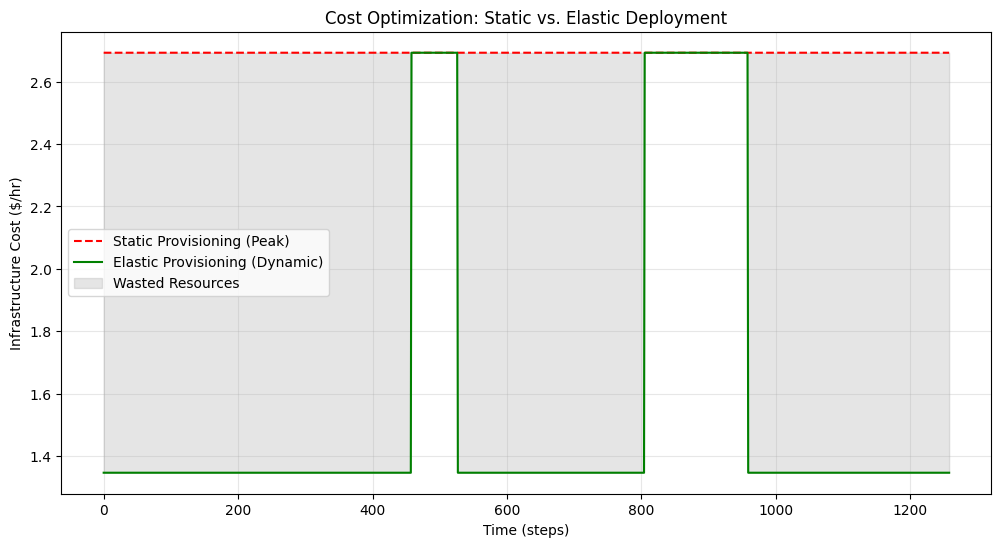

In [17]:
# --- 1. DEFINE A FAST SOLVER FOR THE SIMULATION ---
# Running GA or A* 1200+ times can be slow. We use a fast Greedy heuristic here 
# to demonstrate the elasticity curve quickly. You can swap this with a_star_search
# if you want exact optimality (but it will take longer to run).

def solve_greedy(target_cpu, target_ram, vm_data_sorted):
    """
    Fast greedy algorithm: Always pick the most cost-efficient VM 
    that fits the remaining bottleneck resource.
    """
    current_cpu = 0
    current_ram = 0
    cost = 0
    counts = {v['type']: 0 for v in vm_data_sorted}
    
    # Sort VMs by Cost Efficiency (Cost per CPU + Cost per RAM)
    # This is a simple heuristic strategy
    sorted_options = sorted(vm_data_sorted, key=lambda x: x['cost_per_cpu'] + x['cost_per_ram'])
    
    while current_cpu < target_cpu or current_ram < target_ram:
        # Simple Logic: Find best VM to add
        # Ideally, we want a VM that provides needed resources at lowest cost
        best_vm = None
        
        # Try to find the most efficient available VM
        for vm in sorted_options:
            if counts[vm['type']] < vm['qty_limit']:
                best_vm = vm
                break
        
        if not best_vm: 
            return float('inf') # Constraint violation (ran out of VMs)
            
        # "Rent" this VM
        counts[best_vm['type']] += 1
        current_cpu += best_vm['cpu']
        current_ram += best_vm['ram']
        cost += best_vm['cost']
        
    return cost

# --- 2. PREPARE DATA ---
# Ensure vm_data is ready (from previous steps)
vm_types = list(cost_vm.keys())
vm_data = []
for v in vm_types:
    vm_data.append({
        'type': v, 'cpu': cpu_vm[v], 'ram': ram_vm[v], 
        'cost': cost_vm[v], 'qty_limit': qty_vm[v],
        'cost_per_cpu': cost_vm[v]/cpu_vm[v], 'cost_per_ram': cost_vm[v]/ram_vm[v]
    })

# --- 3. RUN THE ELASTIC SIMULATION ---
print("Starting Elastic Simulation over Workload Trace...")

elastic_costs = []
timestamps = workloadDF['time'].values
input_rates = workloadDF['input_rate'].values

for i, rate in enumerate(input_rates):
    # A. Calculate Dynamic Demand for this specific time t
    # r_i = floor(rate / mu_i) + 1
    current_r_list = {}
    for comp_id in range(4):
        current_r_list[comp_id] = int(np.floor(rate / mu[comp_id])) + 1
    
    # B. Calculate Total Resource Requirement for time t
    t_cpu_req = sum(cpu_req[c] * current_r_list[c] for c in range(4))
    t_ram_req = sum(ram_req[c] * current_r_list[c] for c in range(4))
    
    # C. Solve Optimization for this specific demand
    # (Using Greedy for speed, but this is where you'd call A* or GA)
    cost_t = solve_greedy(t_cpu_req, t_ram_req, vm_data)
    elastic_costs.append(cost_t)

# --- 4. CALCULATE STATIC COST (BASELINE) ---
# The cost if we just provisioned for the PEAK load once and kept it forever
max_rate = max(input_rates)
max_r_list = {c: int(np.floor(max_rate / mu[c])) + 1 for c in range(4)}
max_cpu_req = sum(cpu_req[c] * max_r_list[c] for c in range(4))
max_ram_req = sum(ram_req[c] * max_r_list[c] for c in range(4))

peak_cost = solve_greedy(max_cpu_req, max_ram_req, vm_data)
static_costs = [peak_cost] * len(input_rates)

# --- 5. RESULTS & VISUALIZATION ---
total_elastic_bill = sum(elastic_costs)
total_static_bill = sum(static_costs)
savings = total_static_bill - total_elastic_bill

print(f"\n--- RESULTS ---")
print(f"Total Cost (Static Provisioning): ${total_static_bill:,.2f}")
print(f"Total Cost (Elastic Provisioning): ${total_elastic_bill:,.2f}")
print(f"Potential Savings: ${savings:,.2f} ({savings/total_static_bill*100:.1f}%)")

plt.figure(figsize=(12, 6))
plt.plot(timestamps, static_costs, label='Static Provisioning (Peak)', color='red', linestyle='--')
plt.plot(timestamps, elastic_costs, label='Elastic Provisioning (Dynamic)', color='green')
plt.fill_between(timestamps, elastic_costs, static_costs, color='gray', alpha=0.2, label='Wasted Resources')
plt.xlabel('Time (steps)')
plt.ylabel('Infrastructure Cost ($/hr)')
plt.title('Cost Optimization: Static vs. Elastic Deployment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We end up with a "two-value" cost curve eventhough the workload is highly variable, that's because the algorithm is making sub-optimal decisions due to a "naive" heuristic.

The issue lies in the Greedy Heuristic used in the simulation code (key=lambda x: x['cost_per_cpu'] + x['cost_per_ram']).

Efficiency vs Absolute Cost: This sorting key prioritizes "Cost Efficiency" (Price per Unit) rather than "Total Price."

The "Bus vs. Car" Trap: Large VMs (like T14 or T15 with 80+ CPUs) are often the most "cost-efficient" per unit because they have huge RAM/CPU. The greedy algorithm sees them as the "best deal" and buys one immediately.

Overkill: The workload (even at peak) likely requires only ~16 CPUs. A T14 has 80 CPUs. Buying it covers the demand, but it costs ~$14. Buying a smaller T11 (16 CPUs) might cost only ~$1.35.

The algorithm buys the "Bus" (T14) for one passenger because the "price per seat" is low, instead of buying the "Compact Car" (T11) which has a higher "price per seat" but a much lower total price.

Because one large VM covers the entire range of the workload fluctuations, the cost stays flat.

Starting Elastic Simulation (Best Fit)...

--- RESULTS ---
Peak CPU Demand: 25.0
Total Cost (Static): $8,880.10
Total Cost (Elastic): $2,280.27
Potential Savings: $6,599.84 (74.3%)


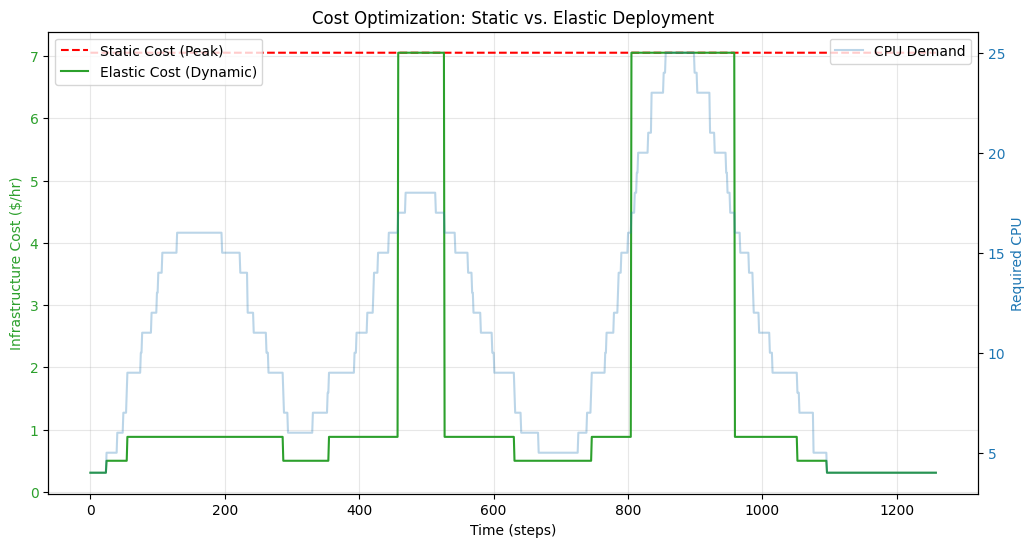

In [18]:
# --- 1. IMPROVED SOLVER: BEST FIT ---
def solve_best_fit(target_cpu, target_ram, vm_data):
    """
    Smarter heuristic: 
    1. First, check if ANY single VM can satisfy the demand cheaper than a combination.
    2. If not, fall back to adding the most cost-effective small VMs.
    """
    
    # Strategy A: One-Shot Fit (Find the cheapest single VM that covers everything)
    valid_single_vms = [
        v for v in vm_data 
        if v['cpu'] >= target_cpu and v['ram'] >= target_ram and v['qty_limit'] > 0
    ]
    
    min_cost = float('inf')
    
    if valid_single_vms:
        # If we can fit in one machine, pick the absolute cheapest one
        best_single = min(valid_single_vms, key=lambda x: x['cost'])
        min_cost = best_single['cost']
    
    # Strategy B: Accumulation (If demand is huge, or combinations are cheaper)
    # We use a greedy approach but prioritize absolute cost for small gaps
    current_cpu = 0
    current_ram = 0
    cost_accum = 0
    counts = {v['type']: 0 for v in vm_data}
    
    # Sort by absolute cost to fill small gaps cheaply
    sorted_by_cost = sorted(vm_data, key=lambda x: x['cost'])
    
    while current_cpu < target_cpu or current_ram < target_ram:
        # Find valid candidate that reduces the gap
        best_add = None
        
        for vm in sorted_by_cost:
            if counts[vm['type']] < vm['qty_limit']:
                best_add = vm
                # Optimization: If this small VM fills the gap, take it immediately
                if (current_cpu + vm['cpu'] >= target_cpu) and (current_ram + vm['ram'] >= target_ram):
                    break
        
        if not best_add:
            cost_accum = float('inf')
            break
            
        counts[best_add['type']] += 1
        current_cpu += best_add['cpu']
        current_ram += best_add['ram']
        cost_accum += best_add['cost']
        
        # Pruning: If accumulation exceeds the best single VM we found, stop
        if cost_accum > min_cost:
            break
            
    return min(min_cost, cost_accum)

# --- 2. PREPARE DATA ---
vm_types = list(cost_vm.keys())
vm_data = []
for v in vm_types:
    vm_data.append({
        'type': v, 'cpu': cpu_vm[v], 'ram': ram_vm[v], 
        'cost': cost_vm[v], 'qty_limit': qty_vm[v]
    })

# --- 3. RUN THE ELASTIC SIMULATION ---
print("Starting Elastic Simulation (Best Fit)...")

elastic_costs = []
timestamps = workloadDF['time'].values
input_rates = workloadDF['input_rate'].values

# Track resource usage for analysis
cpu_usages = []

for i, rate in enumerate(input_rates):
    # A. Calculate Dynamic Demand
    current_r_list = {}
    for comp_id in range(4):
        current_r_list[comp_id] = int(np.floor(rate / mu[comp_id])) + 1
    
    t_cpu_req = sum(cpu_req[c] * current_r_list[c] for c in range(4))
    t_ram_req = sum(ram_req[c] * current_r_list[c] for c in range(4))
    cpu_usages.append(t_cpu_req)
    
    # B. Solve with Best Fit
    cost_t = solve_best_fit(t_cpu_req, t_ram_req, vm_data)
    elastic_costs.append(cost_t)

# --- 4. STATIC BASELINE ---
max_rate = max(input_rates)
max_r_list = {c: int(np.floor(max_rate / mu[c])) + 1 for c in range(4)}
max_cpu = sum(cpu_req[c] * max_r_list[c] for c in range(4))
max_ram = sum(ram_req[c] * max_r_list[c] for c in range(4))

peak_cost = solve_best_fit(max_cpu, max_ram, vm_data)
static_costs = [peak_cost] * len(input_rates)

# --- 5. VISUALIZATION ---
total_elastic = sum(elastic_costs)
total_static = sum(static_costs)
savings = total_static - total_elastic

print(f"\n--- RESULTS ---")
print(f"Peak CPU Demand: {max_cpu}")
print(f"Total Cost (Static): ${total_static:,.2f}")
print(f"Total Cost (Elastic): ${total_elastic:,.2f}")
print(f"Potential Savings: ${savings:,.2f} ({savings/total_static*100:.1f}%)")

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:green'
ax1.set_xlabel('Time (steps)')
ax1.set_ylabel('Infrastructure Cost ($/hr)', color=color)
ax1.plot(timestamps, static_costs, label='Static Cost (Peak)', color='red', linestyle='--')
ax1.plot(timestamps, elastic_costs, label='Elastic Cost (Dynamic)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Add a second axis to show CPU demand scaling
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Required CPU', color=color)  
ax2.plot(timestamps, cpu_usages, color=color, alpha=0.3, label='CPU Demand')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('Cost Optimization: Static vs. Elastic Deployment')
plt.show()